In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau, TensorBoard
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
import json
warnings.filterwarnings('ignore')



In [ ]:
# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
BASE_DIR   = "/content/drive/MyDrive/ML-CEP/data_cropped_128"
MODEL_BASE_PATH = "/content/drive/MyDrive/ML-CEP/model_cnn_scratch_changed_dropoutandfilterSize"

IMG_SIZE   = 128          # 128×128 — good balance of detail vs speed
BATCH_SIZE = 32
NUM_CLASSES = 26
LR         = 1e-3

# Map folder names 1-26 → A-Z labels
LABEL_MAP = {str(i): chr(64 + i) for i in range(1, 27)}
print("Label map:", LABEL_MAP)

Label map: {'1': 'A', '2': 'B', '3': 'C', '4': 'D', '5': 'E', '6': 'F', '7': 'G', '8': 'H', '9': 'I', '10': 'J', '11': 'K', '12': 'L', '13': 'M', '14': 'N', '15': 'O', '16': 'P', '17': 'Q', '18': 'R', '19': 'S', '20': 'T', '21': 'U', '22': 'V', '23': 'W', '24': 'X', '25': 'Y', '26': 'Z'}


In [ ]:
people = ["manahil", "sitwat", "talha", "Marium"]

total_images = 0
print("\n📊 Dataset Summary:")
print("-" * 45)
for folder_num in range(1, 27):
    folder_path = os.path.join(BASE_DIR, str(folder_num))
    letter = LABEL_MAP[str(folder_num)]
    count = 0
    for person in people:
        person_path = os.path.join(folder_path, person)
        if os.path.exists(person_path):
            imgs = [f for f in os.listdir(person_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
            count += len(imgs)
    total_images += count
    print(f"  {folder_num:>2} ({letter}): {count:>5} images")
print("-" * 45)
print(f"  TOTAL : {total_images:>5} images")



📊 Dataset Summary:
---------------------------------------------
   1 (A):   215 images
   2 (B):   200 images
   3 (C):   179 images
   4 (D):   209 images
   5 (E):   214 images
   6 (F):   210 images
   7 (G):   204 images
   8 (H):   196 images
   9 (I):   204 images
  10 (J):   212 images
  11 (K):   210 images
  12 (L):   206 images
  13 (M):   199 images
  14 (N):   200 images
  15 (O):   192 images
  16 (P):   209 images
  17 (Q):   195 images
  18 (R):   215 images
  19 (S):   191 images
  20 (T):   205 images
  21 (U):   200 images
  22 (V):   198 images
  23 (W):   214 images
  24 (X):   211 images
  25 (Y):   210 images
  26 (Z):   220 images
---------------------------------------------
  TOTAL :  5318 images


In [ ]:
from concurrent.futures import ThreadPoolExecutor
import os, shutil

FLAT_DIR = "/content/flat_data"
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp'}

def process_person(args):
    folder_num, person = args
    letter = LABEL_MAP[str(folder_num)]
    dest = os.path.join(FLAT_DIR, letter)
    src = os.path.join(BASE_DIR, str(folder_num), person)
    if not os.path.exists(src):
        return

    with os.scandir(src) as entries:
        for entry in entries:
            if not entry.is_file():
                continue
            if os.path.splitext(entry.name)[1].lower() not in VALID_EXT:
                continue
            dst = os.path.join(dest, f"{person}_{entry.name}")
            try:
                os.link(entry.path, dst)
            except OSError:
                shutil.copy2(entry.path, dst)

if os.path.exists(FLAT_DIR):
    shutil.rmtree(FLAT_DIR)

# Pre-create all dirs first
for folder_num in range(1, 27):
    os.makedirs(os.path.join(FLAT_DIR, LABEL_MAP[str(folder_num)]), exist_ok=True)

tasks = [(f, p) for f in range(1, 27) for p in people]

with ThreadPoolExecutor(max_workers=8) as ex:
    list(ex.map(process_person, tasks))

print("✅ Done!")


⚙️  Building flat directory structure...
✅ Flat structure ready at: /content/flat_data
  A: 215 images
  B: 200 images
  C: 179 images
  D: 209 images
  E: 214 images
  F: 210 images
  G: 204 images
  H: 196 images
  I: 204 images
  J: 212 images
  K: 210 images
  L: 206 images
  M: 199 images
  N: 200 images
  O: 192 images
  P: 209 images
  Q: 195 images
  R: 215 images
  S: 191 images
  T: 205 images
  U: 200 images
  V: 198 images
  W: 214 images
  X: 211 images
  Y: 210 images
  Z: 220 images


In [ ]:
import random
from pathlib import Path

TRAIN_DIR = "/content/split_data/train"
VAL_DIR   = "/content/split_data/val"
TEST_DIR  = "/content/split_data/test"

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)

random.seed(42)

for letter in sorted(os.listdir(FLAT_DIR)):
    src_dir = os.path.join(FLAT_DIR, letter)
    files   = os.listdir(src_dir)
    random.shuffle(files)

    n_total = len(files)
    n_train = int(0.70 * n_total)
    n_val   = int(0.20 * n_total)
    # rest goes to test

    splits = {
        TRAIN_DIR: files[:n_train],
        VAL_DIR  : files[n_train : n_train + n_val],
        TEST_DIR : files[n_train + n_val:]
    }

    for dest_root, split_files in splits.items():
        dest = os.path.join(dest_root, letter)
        os.makedirs(dest, exist_ok=True)
        for f in split_files:
            shutil.copy2(os.path.join(src_dir, f), os.path.join(dest, f))

print("✅ Split complete!")
for split_name, split_dir in [("Train", TRAIN_DIR),
                               ("Val",   VAL_DIR),
                               ("Test",  TEST_DIR)]:
    total = sum(len(os.listdir(os.path.join(split_dir, c)))
                for c in os.listdir(split_dir))
    print(f"  {split_name}: {total} images")

✅ Split complete!
  Train: 3713 images
  Val: 1055 images
  Test: 550 images


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print("\nClass names:", CLASS_NAMES)
print("Train batches:", len(train_gen))
print("Val   batches:", len(val_gen))
print("Test  batches:", len(test_gen))

#

Found 3713 images belonging to 26 classes.
Found 1055 images belonging to 26 classes.
Found 550 images belonging to 26 classes.

Class names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Train batches: 117
Val   batches: 33
Test  batches: 18


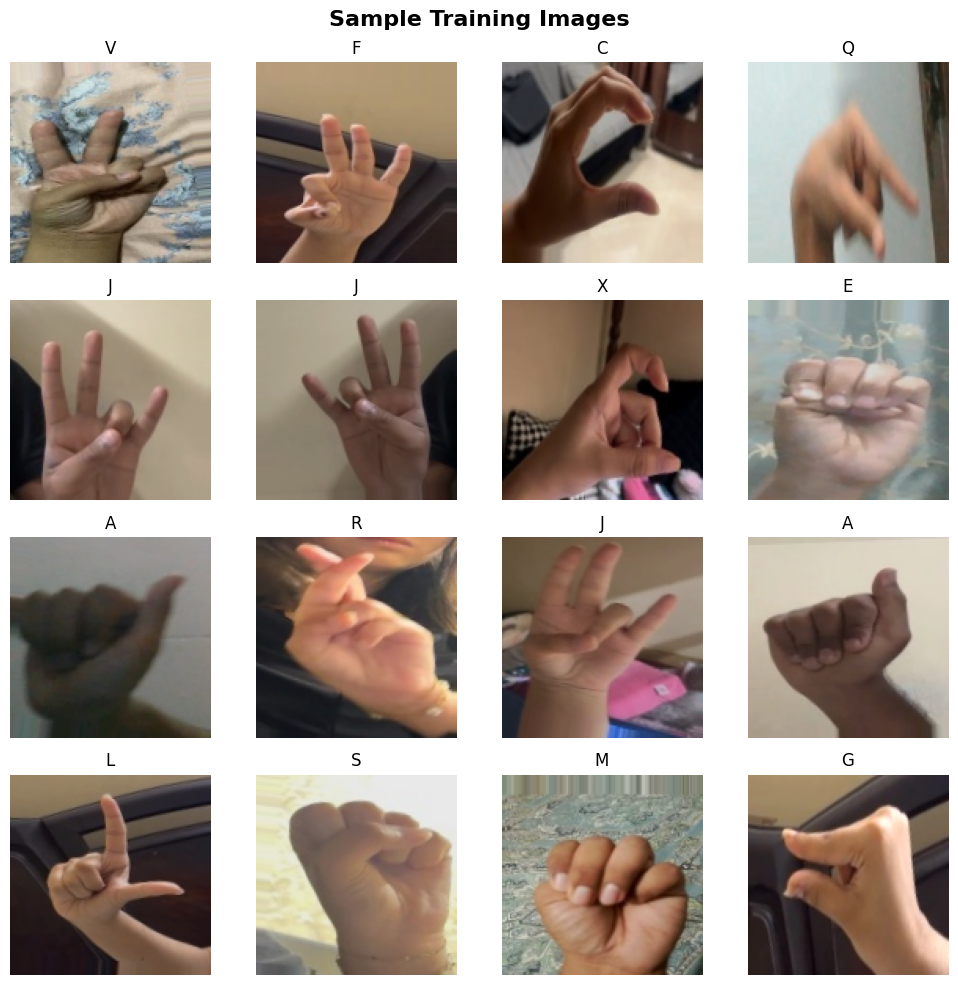

In [ ]:
def show_samples(generator, class_names, n=16):
    imgs, labels = next(generator)
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        if i >= n: break
        ax.imshow(imgs[i])
        ax.set_title(class_names[np.argmax(labels[i])], fontsize=12)
        ax.axis('off')
    plt.suptitle("Sample Training Images", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(train_gen, CLASS_NAMES)

In [ ]:
# ============================================================
# Model Update Summary (Old CNN → New CNN)
# ============================================================

# 1. Reduced Filters:
#    Old: 32→64→128→256→512
#    New: 16→32→64→128→256
#    → Less computation, faster training, reduced overfitting

# 2. Improved SpatialDropout:
#    → Gradually increases with depth
#    → Better regularization in deeper layers

# 3. Optimizer Change:
#    Adam → AdamW
#    → Better generalization via weight decay

# 4. Label Smoothing Added:
#    → Prevents overconfidence
#    → Improves robustness

# 5. Architecture Refinements:
#    → More balanced design for 128x128 input
#    → Improved training stability

# Overall:
#    → Lighter, faster, more generalizable model
# ============================================================

from tensorflow.keras import layers, regularizers, optimizers
from tensorflow.keras.models import Model
import tensorflow as tf

def conv_block(x, filters, kernel_size=3, stride=1,
               use_depthwise=False, dropout_rate=0.1):
    """Convolutional block with BN + ReLU + SpatialDropout"""
    if use_depthwise:
        # Depthwise Separable Convolution
        x = layers.DepthwiseConv2D(kernel_size, padding='same',
                                   use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 1, use_bias=False)(x)  # Pointwise
    else:
        x = layers.Conv2D(filters, kernel_size,
                          strides=stride,
                          padding='same',
                          use_bias=False,
                          kernel_regularizer=regularizers.l2(1e-4))(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    if dropout_rate > 0:
        x = layers.SpatialDropout2D(dropout_rate)(x)

    return x


def residual_block(x, filters):
    """Residual block with two convs + skip connection"""
    shortcut = x

    x = conv_block(x, filters, dropout_rate=0.0)
    x = conv_block(x, filters, dropout_rate=0.0)

    # Adjust shortcut dimensions if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same',
                                 use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x


def build_custom_cnn(input_shape=(128, 128, 3), num_classes=26):
    inputs = keras.Input(shape=input_shape)

    # ── Block 1: 128×128 → 64×64 (16 filters)
    x = conv_block(inputs, 16, dropout_rate=0.1)
    x = residual_block(x, 16)
    x = layers.MaxPooling2D(2)(x)

    # ── Block 2: 64×64 → 32×32 (32 filters)
    x = conv_block(x, 32, dropout_rate=0.12)
    x = residual_block(x, 32)
    x = layers.MaxPooling2D(2)(x)

    # ── Block 3: 32×32 → 16×16 (64 filters)
    x = conv_block(x, 64, dropout_rate=0.15)
    x = residual_block(x, 64)
    x = layers.MaxPooling2D(2)(x)

    # ── Block 4: 16×16 → 8×8 (128 filters + depthwise)
    x = conv_block(x, 128, use_depthwise=True, dropout_rate=0.2)
    x = residual_block(x, 128)
    x = layers.MaxPooling2D(2)(x)

    # ── Block 5: 8×8 → 4×4 (256 filters + depthwise)
    x = conv_block(x, 256, use_depthwise=True, dropout_rate=0.25)
    x = residual_block(x, 256)
    x = layers.MaxPooling2D(2)(x)


    # ── Classification Head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(512, use_bias=False,
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, use_bias=False,
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name="HandSign_CNN_v2_Optimized")
    return model

model = build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                         num_classes=NUM_CLASSES)

model.summary()



Model: "HandSign_CNN_v1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 128, 128,  │          0 │ re_lu[0][0]       │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,216 │ spatial_dropout2… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      9,216 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ re_lu_2[0][0],    │
│                     │ 32)               │            │ spatial_dropout2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 6,962,042 (26.56 MB)

 Trainable params: 6,953,786 (26.53 MB)

 Non-trainable params: 8,256 (32.25 KB)

In [ ]:
optimizer = keras.optimizers.AdamW(
    learning_rate=LR,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy',
             keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)


In [ ]:
import os
import glob

MODEL_PATH      = os.path.join(MODEL_BASE_PATH, "best_handsign_cnn.keras")
CHECKPOINT_DIR  = os.path.join(MODEL_BASE_PATH, "checkpoints")
HISTORY_PATH    = os.path.join(MODEL_BASE_PATH, "training_history.json")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Epoch checkpoint: saves every epoch with epoch number in filename
# ── So if crash at epoch 37, you have epoch_036.keras to resume from
EPOCH_CKPT_PATH = os.path.join(CHECKPOINT_DIR, "epoch_{epoch:03d}_valacc{val_accuracy:.4f}.keras")

callbacks = [
    # ✅ Save BEST model (by val_accuracy)
    ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    # ✅ Save EVERY epoch (for crash recovery)
    # Keeps only last 3 to save Drive space
    ModelCheckpoint(
        EPOCH_CKPT_PATH,
        monitor='val_accuracy',
        save_best_only=False,       # save EVERY epoch
        save_weights_only=False,
        verbose=0
    ),

    # ✅ Early stopping
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),

    # ✅ Reduce LR on plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=6,
        min_lr=1e-6,
        verbose=1
    ),

    # ✅ TensorBoard
    TensorBoard(log_dir='/content/logs', histogram_freq=1)
]

# ============================================================
# 🔧 STEP 11B: Helper — Save & Load Training History
# ============================================================


def save_history(history_obj, path, phase_key="phase1"):
    """Append history from a training run to a JSON file."""
    data = {}
    if os.path.exists(path):
        with open(path, "r") as f:
            data = json.load(f)
    data[phase_key] = {
        k: [float(x) for x in v]
        for k, v in history_obj.history.items()
    }
    with open(path, "w") as f:
        json.dump(data, f, indent=2)
    print(f"✅ History saved → {path}")

def load_history(path):
    """Load combined history dict from JSON."""
    if not os.path.exists(path):
        return {}
    with open(path, "r") as f:
        return json.load(f)

# ============================================================
# 🔧 STEP 11C: Helper — Find Latest Checkpoint to Resume From
# ============================================================
def find_latest_checkpoint(ckpt_dir):
    """
    Scans checkpoint directory and returns path to the
    most recently saved epoch checkpoint, or None.
    """
    pattern = os.path.join(ckpt_dir, "epoch_*.keras")
    checkpoints = sorted(glob.glob(pattern))
    if checkpoints:
        latest = checkpoints[-1]
        # Extract epoch number from filename
        basename = os.path.basename(latest)          # epoch_036_valacc0.9312.keras
        epoch_num = int(basename.split("_")[1])      # 36
        print(f"🔍 Found checkpoint: {latest}")
        print(f"   → Resuming from epoch {epoch_num}")
        return latest, epoch_num
    return None, 0

def cleanup_old_checkpoints(ckpt_dir, keep=3):
    """Keep only the last `keep` epoch checkpoints to save Drive space."""
    pattern = os.path.join(ckpt_dir, "epoch_*.keras")
    checkpoints = sorted(glob.glob(pattern))
    to_delete = checkpoints[:-keep]
    for ckpt in to_delete:
        os.remove(ckpt)
        print(f"🗑️  Deleted old checkpoint: {os.path.basename(ckpt)}")

In [ ]:
# ── Auto-detect if we should resume
latest_ckpt, initial_epoch = find_latest_checkpoint(CHECKPOINT_DIR)

if latest_ckpt:
    print(f"\n♻️  RESUMING training from: {latest_ckpt}")
    print(f"   Starting at epoch: {initial_epoch + 1}")
    model = keras.models.load_model(latest_ckpt)
    print("✅ Model weights loaded successfully!")
else:
    print("\n🆕 No checkpoint found — Starting fresh training")
    initial_epoch = 0

# ────────────────────────────────────────────
# PHASE 1: Main Training
# ────────────────────────────────────────────
PHASE1_TOTAL_EPOCHS = 40

# Only run Phase 1 if we haven't finished it yet
if initial_epoch < PHASE1_TOTAL_EPOCHS:
    print("\n" + "="*55)
    print(f"🚀 PHASE 1: Main Training  (LR = 1e-3)")
    print(f"   Epochs: {initial_epoch + 1} → {PHASE1_TOTAL_EPOCHS}")
    print("="*55)

    history1 = model.fit(
        train_gen,
        epochs=PHASE1_TOTAL_EPOCHS,
        initial_epoch=initial_epoch,       # ← KEY: tells Keras where to resume
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1
    )

    save_history(history1, HISTORY_PATH, phase_key="phase1")
    cleanup_old_checkpoints(CHECKPOINT_DIR, keep=3)
    print("✅ Phase 1 complete!")

else:
    print(f"✅ Phase 1 already complete (checkpoint epoch {initial_epoch}). Skipping.")
    history1 = None

# ────────────────────────────────────────────
# PHASE 2: Fine-Tuning at lower LR
# ────────────────────────────────────────────
PHASE2_TOTAL_EPOCHS = 60  # Phase 1 (40) + Phase 2 (20) = 70 total

# Only run Phase 2 if we haven't finished it
if initial_epoch < PHASE2_TOTAL_EPOCHS:
    phase2_initial = max(initial_epoch, PHASE1_TOTAL_EPOCHS)

    print("\n" + "="*55)
    print(f"🔬 PHASE 2: Fine-Tuning  (LR = 1e-4)")
    print(f"   Epochs: {phase2_initial + 1} → {PHASE2_TOTAL_EPOCHS}")
    print("="*55)

    # Lower the LR for fine-tuning
    model.optimizer.learning_rate = 1e-4
    print(f"   Current LR set to: {keras.backend.get_value(model.optimizer.learning_rate):.6f}")

    history2 = model.fit(
        train_gen,
        epochs=PHASE2_TOTAL_EPOCHS,
        initial_epoch=phase2_initial,      # ← resumes from correct epoch
        validation_data=val_gen,
        callbacks=[
            ModelCheckpoint(MODEL_PATH,
                            monitor='val_accuracy',
                            save_best_only=True,
                            verbose=1),
            ModelCheckpoint(EPOCH_CKPT_PATH,
                            save_best_only=False,
                            verbose=0),
            EarlyStopping(monitor='val_accuracy',
                          patience=10,
                          restore_best_weights=True,
                          verbose=1),
            ReduceLROnPlateau(monitor='val_loss',
                              factor=0.3,
                              patience=5,
                              min_lr=1e-6,
                              verbose=1),
        ],
        verbose=1
    )

    save_history(history2, HISTORY_PATH, phase_key="phase2")
    cleanup_old_checkpoints(CHECKPOINT_DIR, keep=3)
    print("✅ Phase 2 complete!")

else:
    print(f"✅ Phase 2 already complete (checkpoint epoch {initial_epoch}). Skipping.")
    history2 = None

print("\n🎉 Training finished! All weights saved to Drive.")
print(f"   Best model : {MODEL_PATH}")
print(f"   Checkpoints: {CHECKPOINT_DIR}")
print(f"   History    : {HISTORY_PATH}")


🆕 No checkpoint found — Starting fresh training

🚀 PHASE 1: Main Training  (LR = 1e-3)
   Epochs: 1 → 40
Epoch 1/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.0365 - loss: 4.0764 - top3_acc: 0.1167
Epoch 1: val_accuracy improved from None to 0.03697, saving model to /content/drive/MyDrive/ML-CEP/model1/best_handsign_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ML-CEP/model1/best_handsign_cnn.keras
117/117 ━━━━━━━━━━━━━━━━━━━━ 91s 465ms/step - accuracy: 0.0377 - loss: 3.9913 - top3_acc: 0.1180 - val_accuracy: 0.0370 - val_loss: 3.5964 - val_top3_acc: 0.1147 - learning_rate: 0.0010
Epoch 2/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.0387 - loss: 3.8639 - top3_acc: 0.1118
Epoch 2: val_accuracy did not improve from 0.03697
117/117 ━━━━━━━━━━━━━━━━━━━━ 28s 240ms/step - accuracy: 0.0401 - loss: 3.8392 - top3_acc: 0.1147 - val_accuracy: 0.0360 - val_loss: 3.5946 - val_top3_acc: 0.1232 - learning_rate: 0.0010
Epoch 3/40
117/117 ━━━━━━━━━━━━

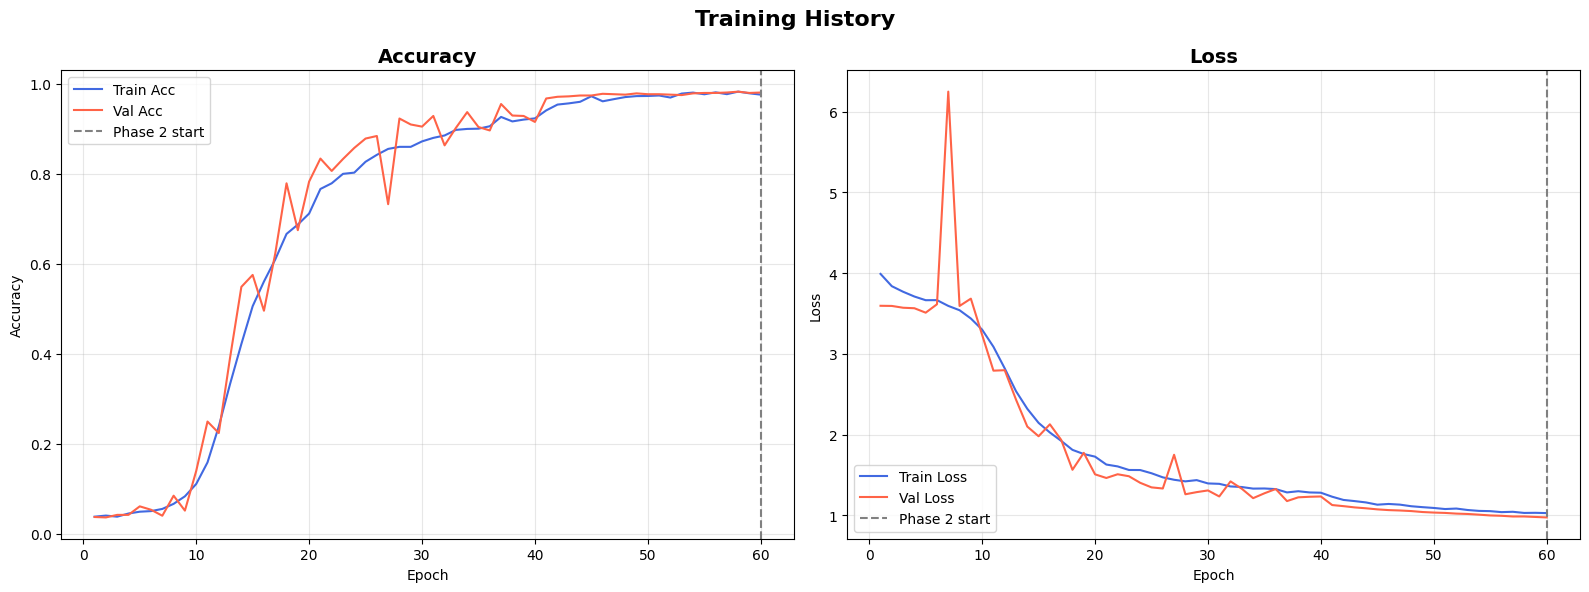

In [ ]:
def plot_training_history(history_path=HISTORY_PATH, show_phase_line=True):
    """Plot training history from saved JSON (works even if training crashed)."""
    data = load_history(history_path)

    if not data:
        print("❌ No training history found to plot.")
        return

    # Merge phase1 and phase2
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    phase_split = None

    if 'phase1' in data:
        acc.extend(data['phase1'].get('accuracy', []))
        val_acc.extend(data['phase1'].get('val_accuracy', []))
        loss.extend(data['phase1'].get('loss', []))
        val_loss.extend(data['phase1'].get('val_loss', []))
        phase_split = len(acc)

    if 'phase2' in data:
        acc.extend(data['phase2'].get('accuracy', []))
        val_acc.extend(data['phase2'].get('val_accuracy', []))
        loss.extend(data['phase2'].get('loss', []))
        val_loss.extend(data['phase2'].get('val_loss', []))

    if not acc:
        print("❌ No accuracy data found in history.")
        return

    epochs_range = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Accuracy Plot
    ax1.plot(epochs_range, acc, label='Train Accuracy', color='royalblue')
    ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color='tomato')
    if show_phase_line and phase_split:
        ax1.axvline(phase_split, color='gray', linestyle='--', label='Phase 2 Start')
    ax1.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss Plot
    ax2.plot(epochs_range, loss, label='Train Loss', color='royalblue')
    ax2.plot(epochs_range, val_loss, label='Validation Loss', color='tomato')
    if show_phase_line and phase_split:
        ax2.axvline(phase_split, color='gray', linestyle='--', label='Phase 2 Start')
    ax2.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Hand Sign CNN Training History', fontsize=16, fontweight='bold')
    plt.tight_layout()

    save_path = os.path.join(MODEL_BASE_PATH, 'training_history.png')
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    print(f"✅ Plot saved to: {save_path}")
    plt.show()
    print("\n📊 Generating training history plot...")
plot_training_history()

In [ ]:
print("\n" + "="*55)
print("🧪 TEST SET EVALUATION")
print("="*55)

# Load best saved model
best_model = keras.models.load_model(MODEL_PATH)

test_loss, test_acc, test_top3 = best_model.evaluate(test_gen, verbose=1)
print(f"\n✅ Test Accuracy  : {test_acc * 100:.2f}%")
print(f"✅ Top-3 Accuracy : {test_top3 * 100:.2f}%")
print(f"✅ Test Loss      : {test_loss:.4f}")



🧪 TEST SET EVALUATION
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 269ms/step - accuracy: 0.9745 - loss: 1.0062 - top3_acc: 0.9927

✅ Test Accuracy  : 97.45%
✅ Top-3 Accuracy : 99.27%
✅ Test Loss      : 1.0062


18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step

📋 Classification Report:
              precision    recall  f1-score   support

           A       0.96      1.00      0.98        22
           B       0.95      0.95      0.95        20
           C       1.00      1.00      1.00        19
           D       0.92      1.00      0.96        22
           E       0.92      1.00      0.96        23
           F       1.00      1.00      1.00        21
           G       1.00      0.95      0.98        22
           H       0.95      1.00      0.98        20
           I       1.00      0.86      0.93        22
           J       1.00      0.91      0.95        22
           K       1.00      1.00      1.00        21
           L       1.00      1.00      1.00        21
           M       0.95      1.00      0.98        21
           N       1.00      0.85      0.92        20
           O       0.95      0.95      0.95        20
           P       1.00      1.00      1.00        22
           Q  

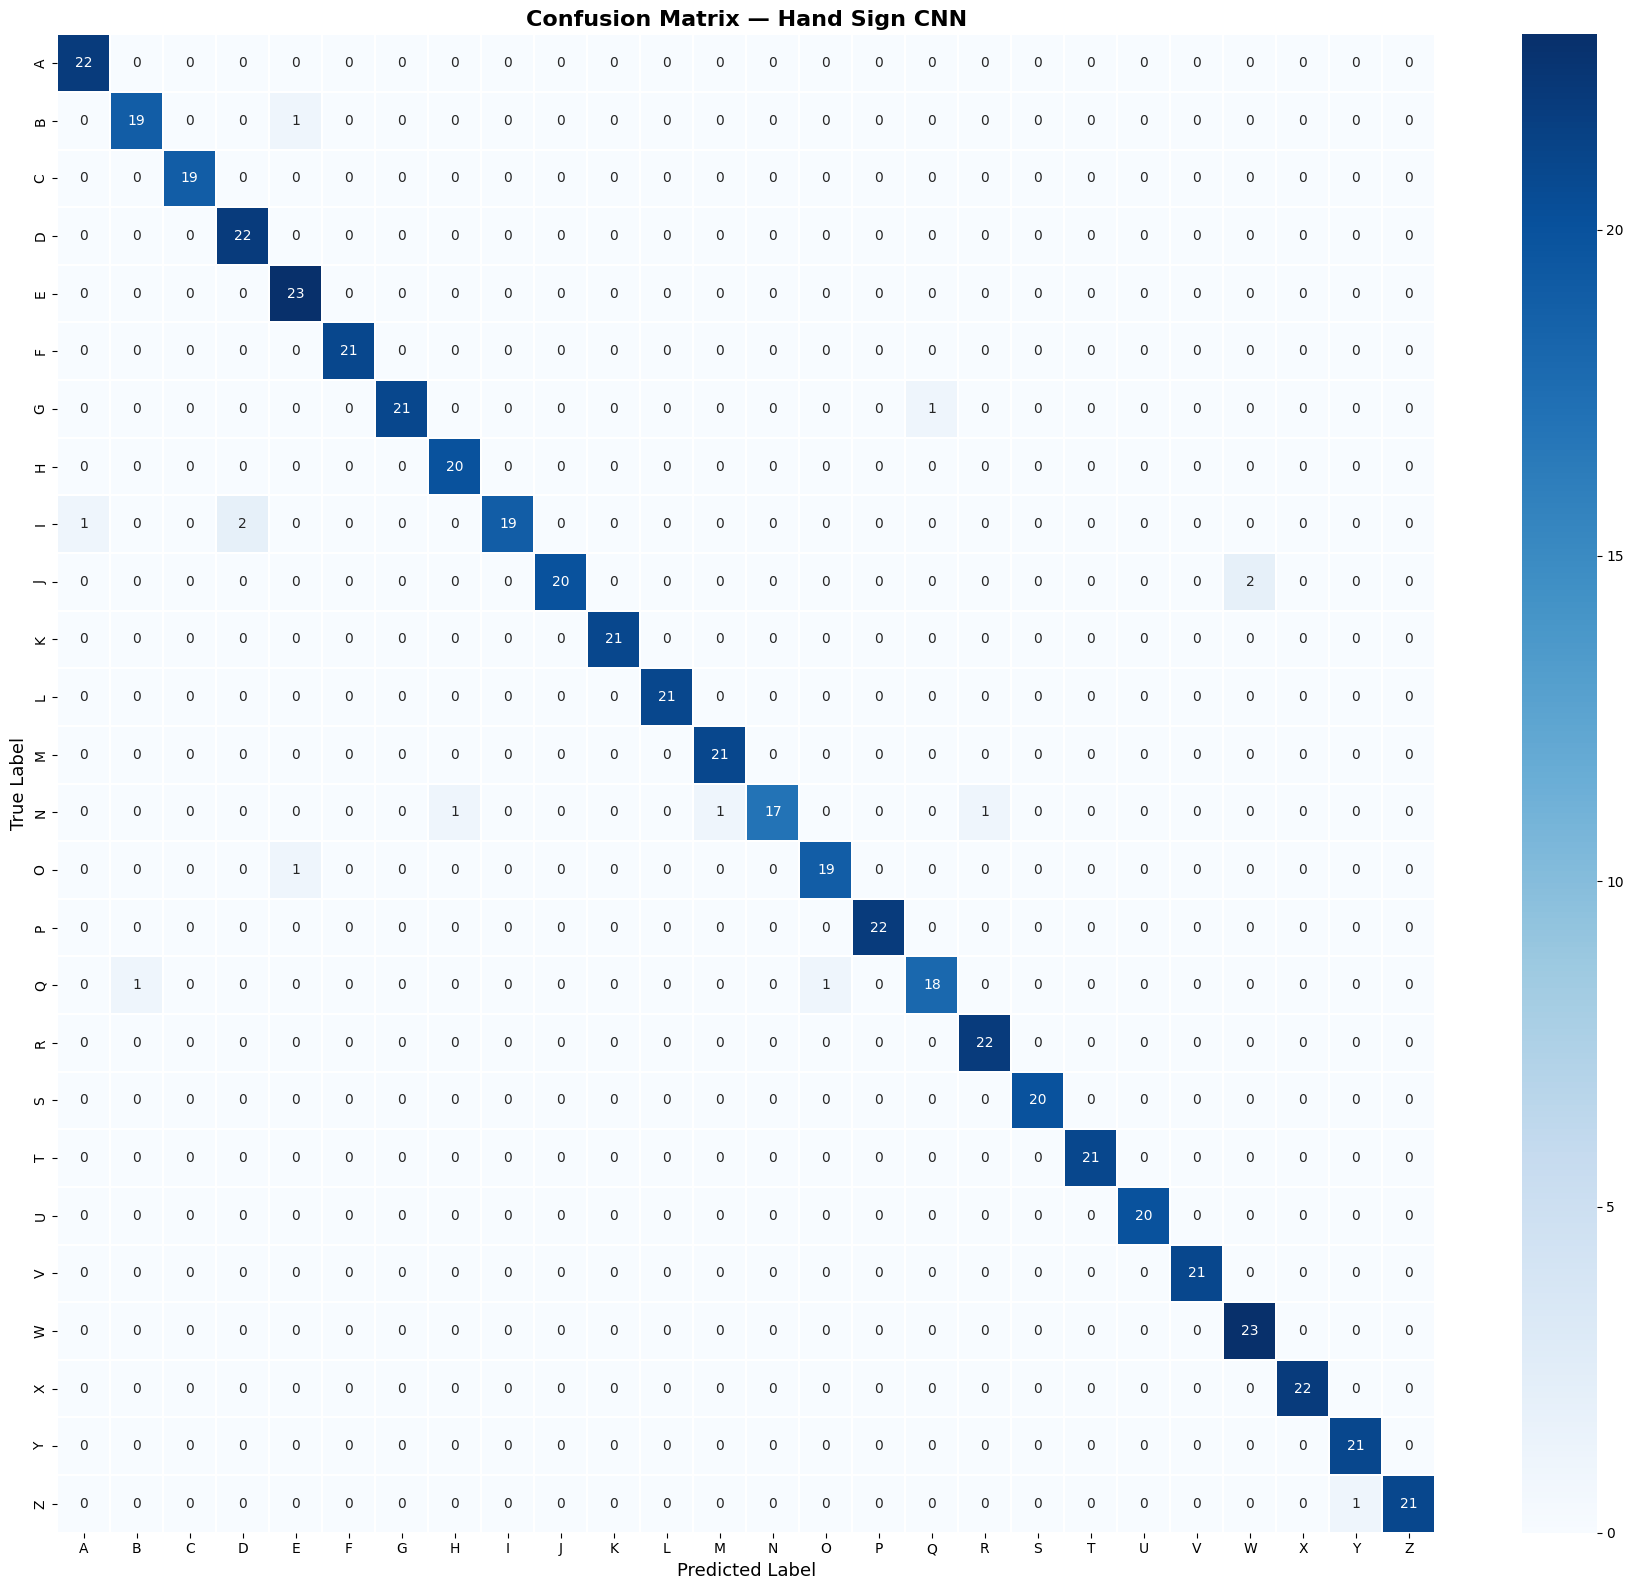

In [ ]:
test_gen.reset()
y_pred_probs = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred,
                             target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(18, 16))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.3)
plt.title('Confusion Matrix — Hand Sign CNN', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=13)
plt.xlabel('Predicted Label', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_BASE_PATH, 'confusion_matrix.png'), dpi=150)
plt.show()

In [ ]:
print("\n📊 Per-Class Accuracy:")
print("-" * 30)
for i, cls in enumerate(CLASS_NAMES):
    mask = (y_true == i)
    if mask.sum() == 0:
        continue
    cls_acc = (y_pred[mask] == y_true[mask]).mean() * 100
    bar = "█" * int(cls_acc / 5)
    print(f"  {cls}: {cls_acc:6.2f}%  {bar}")



📊 Per-Class Accuracy:
------------------------------
  A: 100.00%  ████████████████████
  B:  95.00%  ███████████████████
  C: 100.00%  ████████████████████
  D: 100.00%  ████████████████████
  E: 100.00%  ████████████████████
  F: 100.00%  ████████████████████
  G:  95.45%  ███████████████████
  H: 100.00%  ████████████████████
  I:  86.36%  █████████████████
  J:  90.91%  ██████████████████
  K: 100.00%  ████████████████████
  L: 100.00%  ████████████████████
  M: 100.00%  ████████████████████
  N:  85.00%  █████████████████
  O:  95.00%  ███████████████████
  P: 100.00%  ████████████████████
  Q:  90.00%  ██████████████████
  R: 100.00%  ████████████████████
  S: 100.00%  ████████████████████
  T: 100.00%  ████████████████████
  U: 100.00%  ████████████████████
  V: 100.00%  ████████████████████
  W: 100.00%  ████████████████████
  X: 100.00%  ████████████████████
  Y: 100.00%  ████████████████████
  Z:  95.45%  ███████████████████


In [ ]:
# 1. Keras format (already saved as best)
print(f"\n✅ Best model saved: {MODEL_PATH}")

# 2. Save label map
import json
label_map_path = os.path.join(MODEL_BASE_PATH, "class_indices.json")
with open(label_map_path, "w") as f:
    json.dump(train_gen.class_indices, f)
print(f"✅ Class indices saved: {label_map_path}")

# 3. TFLite (for deployment / mobile)
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
tflite_path    = os.path.join(MODEL_BASE_PATH, "handsign_cnn.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print(f"✅ TFLite model saved: {tflite_path}")



✅ Best model saved: /content/drive/MyDrive/ML-CEP/model1/best_handsign_cnn.keras
✅ Class indices saved: /content/drive/MyDrive/ML-CEP/model1/class_indices.json
Saved artifact at '/tmp/tmpdinl0jd6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  136954835035600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136954835037136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136954835037712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136954835035408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136954835038864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136954835040784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136954835041360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136954835040208: TensorSpec(shape=(), dtype=tf.resource, name=N